# 00 — Single run

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from phd.config import load_config, copy_config
import phd.models.cm.side_loaded_plate as slp
from phd.io import save_run_data as save_run_data_generic
from phd.io import load_run as load_run_generic

from phd.plot import get_current_config as plt_cfg, book_config, book_compact_config, A4_config, KUL_CYCLE

book_config.set_as_current()
page_width = plt_cfg().page_width

save_fig = True
save_table = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (missing pyproject.toml).")

PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "01_side_loaded_plate"
IMAGE_DIR = CHAPTER_DIR / "images"
PDF_DIR = IMAGE_DIR / "pdf"
TABLE_DIR = CHAPTER_DIR / "tables"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PDF_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_ROOT = PROJECT_ROOT / "results" / "side_loaded_plate"
print(f"Project root: {PROJECT_ROOT}")
print(f"Results root: {RESULTS_ROOT}")

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



Project root: /home/r2d2/code/PhD
Results root: /home/r2d2/code/PhD/results/side_loaded_plate


In [2]:
def build_martins_cfg(seed: int = 0, save_fields: bool = True, task: str = "inverse", material_law: str = "isotropic"):
    cfg = load_config("side_loaded_plate")

    cfg.seed = seed
    cfg.task.type = task

    cfg.model.net_type = "SPINN"
    cfg.model.formulation = "mixed"
    cfg.model.architecture.n_hidden = 3
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32

    cfg.problem.material.law = material_law
    cfg.problem.geometry.length = 100.0
    cfg.problem.loading.m = 0.3
    cfg.problem.loading.b = 50.0

    cfg.training.n_iter = 60000
    cfg.training.lr_decay = ["warmup cosine", 1e-4, 5e-3, 1000, 50000, 5e-4]
    cfg.training.log_every = 250
    cfg.training.num_domain = 200 ** 2
    cfg.training.lr = 1e-3
    cfg.training.coord_normalization = True
    cfg.training.stress_bc = True
    cfg.training.self_attention.enabled = False
    cfg.training.loss_normalization.scheme = "grad_norm"

    cfg.task.inverse.measurements.type = "displacement"
    cfg.task.inverse.measurements.n_observations.x = 25
    cfg.task.inverse.measurements.n_observations.y = 25
    cfg.task.inverse.measurements.noise_ratio = 1e-4

    cfg.results.base_dir = str(PROJECT_ROOT / "results")
    cfg.results.save_on_disk = False
    cfg.results.experiment_name = None

    if save_fields:
        cfg.problem.log_fields = ["Ux", "Uy", "Sxx", "Syy", "Sxy"]
    else:
        cfg.problem.log_fields = []

    return cfg

cfg_preview = build_martins_cfg(seed=0, save_fields=True)
print(f"Model: {cfg_preview.model.net_type} / {cfg_preview.model.formulation}")
print(f"Measurements: {cfg_preview.task.inverse.measurements.type}, {cfg_preview.task.inverse.measurements.n_observations.x}x{cfg_preview.task.inverse.measurements.n_observations.y}")
print(f"Noise ratio: {cfg_preview.task.inverse.measurements.noise_ratio}")
print(f"Geometry length: {cfg_preview.problem.geometry.length}")

Model: SPINN / mixed
Measurements: displacement, 25x25
Noise ratio: 0.0001
Geometry length: 100.0


In [3]:
# 1) Single reference run with field logging
single_mode = "load"  # "run" or "load"

task = "inverse" # "forward" or "inverse"
material_law = "orthotropic" # "isotropic", "orthotropic"
single_run_name = f"{task}_{material_law}"

if single_mode == "run":
    cfg_single = build_martins_cfg(seed=0, save_fields=True, task=task, material_law=material_law)
    results_single = slp.train(cfg_single)
    single_run_dir = slp.save_run_data(results_single, run_name=single_run_name)
else:
    results_single = slp.load_run(single_run_name)
    single_run_dir = Path(results_single["run_dir"])

print(f"Single run [{single_mode}] at: {single_run_dir}")

Single run [load] at: /home/r2d2/code/PhD/results/side_loaded_plate/inverse_orthotropic


/home/r2d2/code/PhD/src/phd/plot/plot_util.py:247: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter([], [], c=color, zorder=4,


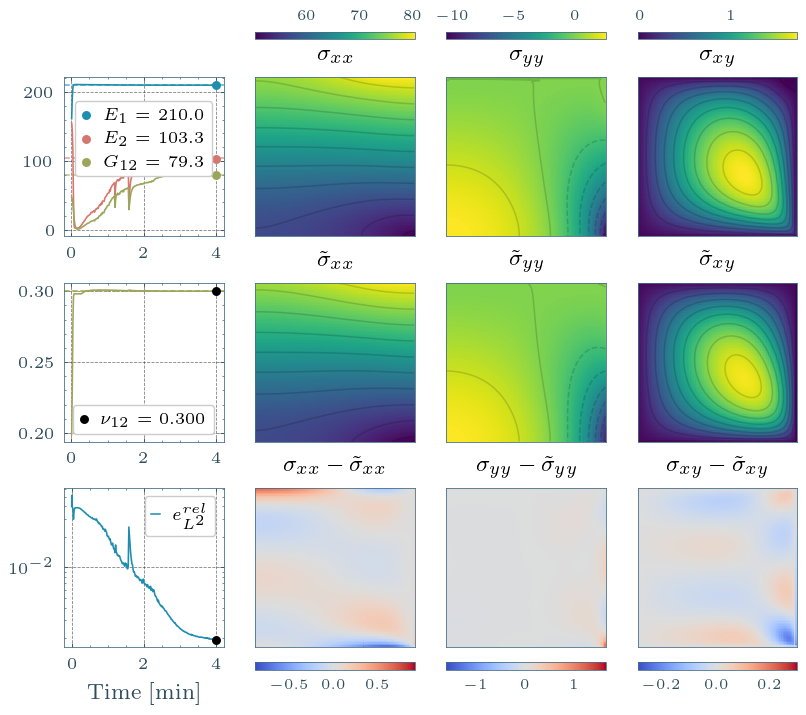

In [4]:
# Plot and save the single-run results (analytical-plate style)
fig, artists = slp.plot_results(
    results_single,
    iteration=-1,
    step_type="time",
    time_unit="min",
    fields=["Sxx", "Syy", "Sxy"],
    plot_contours=True,
    dpi=200,
    show_metrics=True,
    show_residual=True,
    show_iter=False,
    metrics=["L2 Error"],
)
plt.show()

# if save_fig:
#     figure_name = "comparison_Martins_results"
#     fig.savefig(IMAGE_DIR / f"{figure_name}.png", bbox_inches="tight", dpi=300)
#     fig.savefig(PDF_DIR / f"{figure_name}.pdf", bbox_inches="tight")
#     print(f"Saved: {IMAGE_DIR / (figure_name + '.png')}")
#     print(f"Saved: {PDF_DIR / (figure_name + '.pdf')}")

In [6]:
import importlib

import phd.plot.plot_util as plot_util
import phd.plot.plot_cm as plot_cm
import phd.plot as phd_plot
import phd.models.cm.deep_notched as dn

# Reload in dependency order so deep_notched rebinds updated plot functions
plot_util = importlib.reload(plot_util)
plot_cm = importlib.reload(plot_cm)
phd_plot = importlib.reload(phd_plot)
dn = importlib.reload(dn)


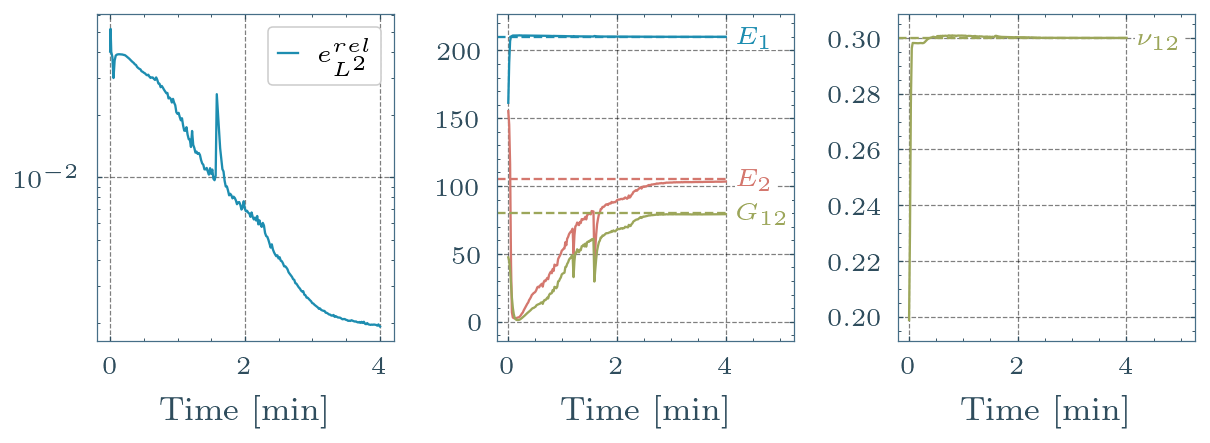

In [7]:
fig, ax = plt.subplots(1,3, figsize=(page_width, page_width*0.3), dpi=300, gridspec_kw={"wspace": 0.35})
fig, ax = plot_cm.plot_variables_and_metric_simple(results_single, fig=fig, ax=ax)

# if save_fig:
#     figure_name = "orthotropic_material_parameters"
#     fig.savefig(IMAGE_DIR / f"{figure_name}.png", bbox_inches="tight", dpi=300)
#     fig.savefig(PDF_DIR / f"{figure_name}.pdf", bbox_inches="tight")
#     print(f"Saved: {IMAGE_DIR / (figure_name + '.png')}")
#     print(f"Saved: {PDF_DIR / (figure_name + '.pdf')}")